# Vectorized Backtesting of an SMA Crossover Strategy

This notebook shows how to take a simple 50-day / 200-day moving average crossover rule on EUR/USD daily price data and evaluate it with a vectorized backtest. We will compare the strategy against a buy-and-hold benchmark using log returns, cumulative performance, and a few simple summary statistics.

**Educational disclaimer:** this notebook is for learning purposes only and is not financial advice or an investment recommendation.


## 1. Imports and Setup

We use `pandas` for time series handling, `numpy` for numerical calculations, and `matplotlib` for plotting. The charts are kept simple and readable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')


## 2. Load and Inspect the Data

The notebook first looks for `EURUSD.csv` in the current working directory. If it is not available, it falls back to `eurusd.csv`, and if neither file exists it creates a synthetic EUR/USD series so the notebook still runs end to end.


In [2]:
try:
    df = pd.read_csv("EURUSD.csv")
    data_source = "Loaded from EURUSD.csv"
except FileNotFoundError:
    try:
        df = pd.read_csv("eurusd.csv")
        data_source = "Loaded from eurusd.csv"
    except FileNotFoundError:
        rng = np.random.default_rng(42)
        trading_days = pd.date_range("2010-01-01", "2020-12-31", freq="B")
        log_moves = rng.normal(loc=0.0, scale=0.0045, size=len(trading_days))
        synthetic_price = 1.30 * np.exp(np.cumsum(log_moves))
        df = pd.DataFrame({"Date": trading_days, "price": synthetic_price})
        data_source = "Synthetic EUR/USD fallback (CSV not found)"

# Parse the date column and move it into the index.
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date", "price"]).set_index("Date").sort_index()

print(data_source)
print()
print("First five rows:")
print(df.head())
print()
print("Basic info:")
df.info()
print()
print("Missing values by column:")
print(df.isna().sum())


Synthetic EUR/USD fallback (CSV not found)

First five rows:
              price
Date               
2010-01-01 1.301784
2010-01-04 1.295706
2010-01-05 1.300089
2010-01-06 1.305603
2010-01-07 1.294191

Basic info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2870 entries, 2010-01-01 to 2020-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   2870 non-null   float64
dtypes: float64(1)
memory usage: 44.8 KB

Missing values by column:
price    0
dtype: int64


## 3. Create the Moving Averages

The strategy uses two simple moving averages: a 50-day average to represent the shorter trend and a 200-day average to represent the longer trend. When the shorter trend rises above the longer trend, the strategy becomes bullish.


In [3]:
# Build the short and long moving averages.
df["SMA_Short"] = df["price"].rolling(window=50).mean()
df["SMA_Long"] = df["price"].rolling(window=200).mean()

df[["price", "SMA_Short", "SMA_Long"]].head(10)


,price,SMA_Short,SMA_Long
Date,,,
2010-01-01,1.301784,NaN,NaN
2010-01-04,1.295706,NaN,NaN
2010-01-05,1.300089,NaN,NaN
2010-01-06,1.305603,NaN,NaN
2010-01-07,1.294191,NaN,NaN
2010-01-08,1.286629,NaN,NaN
2010-01-11,1.287369,NaN,NaN
2010-01-12,1.285539,NaN,NaN
2010-01-13,1.285442,NaN,NaN


## 4. Define the Trading Position

We define a very simple position rule:

- `1` when `SMA_Short > SMA_Long`
- `-1` when `SMA_Short < SMA_Long`
- `0` only if the two moving averages are exactly equal

Here, **long** means betting that EUR/USD will rise, while **short** means betting that EUR/USD will fall.


In [4]:
# Translate the SMA relationship into a trading position.
df["position"] = np.where(
    df["SMA_Short"] > df["SMA_Long"],
    1,
    np.where(df["SMA_Short"] < df["SMA_Long"], -1, 0)
)

df[["price", "SMA_Short", "SMA_Long", "position"]].tail(10)


,price,SMA_Short,SMA_Long,position
Date,,,,
2020-12-18,0.901360,0.886449,0.870523,1
2020-12-21,0.903931,0.887053,0.870665,1
2020-12-22,0.900750,0.887626,0.870798,1
2020-12-23,0.913237,0.888491,0.871021,1
2020-12-24,0.908785,0.889267,0.871231,1
2020-12-25,0.903657,0.889981,0.871412,1
2020-12-28,0.905734,0.890851,0.871612,1
2020-12-29,0.911989,0.891786,0.871848,1
2020-12-30,0.912254,0.892667,0.872086,1


## 5. Calculate Returns

We use daily log returns for the benchmark and for the strategy:

- `returns` = daily log return of the EUR/USD price
- `strategy` = lagged position multiplied by the daily return

The position must be shifted by one day. The reason is important: the signal is generated using the closing prices at the end of day **t**, so the earliest realistic trade based on that information can be held on day **t+1**. Without the shift, we would accidentally use future information and create look-ahead bias.


In [5]:
# Buy-and-hold log returns.
df["returns"] = np.log(df["price"] / df["price"].shift(1))

# Strategy returns use yesterday's position to avoid look-ahead bias.
df["strategy"] = df["position"].shift(1) * df["returns"]

# Remove rows where moving averages or returns are not yet available.
df = df.dropna().copy()

df[["price", "SMA_Short", "SMA_Long", "position", "returns", "strategy"]].head()


,price,SMA_Short,SMA_Long,position,returns,strategy
Date,,,,,,
2010-10-07,1.264856,1.250800,1.280713,-1,-0.000735,-0.000000
2010-10-08,1.266779,1.251026,1.280538,-1,0.001519,-0.001519
2010-10-11,1.274828,1.251530,1.280434,-1,0.006334,-0.006334
2010-10-12,1.275348,1.252233,1.280310,-1,0.000408,-0.000408
2010-10-13,1.279049,1.253063,1.280178,-1,0.002898,-0.002898


## 6. Compare Buy-and-Hold vs Strategy

Now we compare total log returns, terminal values, annualized mean returns, and annualized volatility. The annualization assumes 252 trading days per year.


In [6]:
trading_days = 252

# Total log returns over the full sample.
buy_hold_total_log_return = df["returns"].sum()
strategy_total_log_return = df["strategy"].sum()

# Terminal value of 1 unit invested.
buy_hold_terminal_value = np.exp(buy_hold_total_log_return)
strategy_terminal_value = np.exp(strategy_total_log_return)

# Annualized mean log return and annualized volatility.
buy_hold_ann_mean = df["returns"].mean() * trading_days
strategy_ann_mean = df["strategy"].mean() * trading_days

buy_hold_ann_vol = df["returns"].std() * np.sqrt(trading_days)
strategy_ann_vol = df["strategy"].std() * np.sqrt(trading_days)

comparison = pd.DataFrame({
    "Metric": [
        "Total Log Return",
        "Terminal Value of 1",
        "Annualized Mean Log Return",
        "Annualized Volatility"
    ],
    "Buy and Hold": [
        buy_hold_total_log_return,
        buy_hold_terminal_value,
        buy_hold_ann_mean,
        buy_hold_ann_vol
    ],
    "SMA Strategy": [
        strategy_total_log_return,
        strategy_terminal_value,
        strategy_ann_mean,
        strategy_ann_vol
    ]
})

print(comparison)


                       Metric  Buy and Hold  SMA Strategy
0            Total Log Return     -0.324956     -0.032917
1         Terminal Value of 1      0.722559      0.967619
2  Annualized Mean Log Return     -0.030659     -0.003106
3       Annualized Volatility      0.072373      0.072399


## 7. Cumulative Performance

A clean way to compare the benchmark and the strategy is to track how 1 unit grows over time. Because we are working with log returns, we exponentiate the cumulative sums to convert them into a growth series.


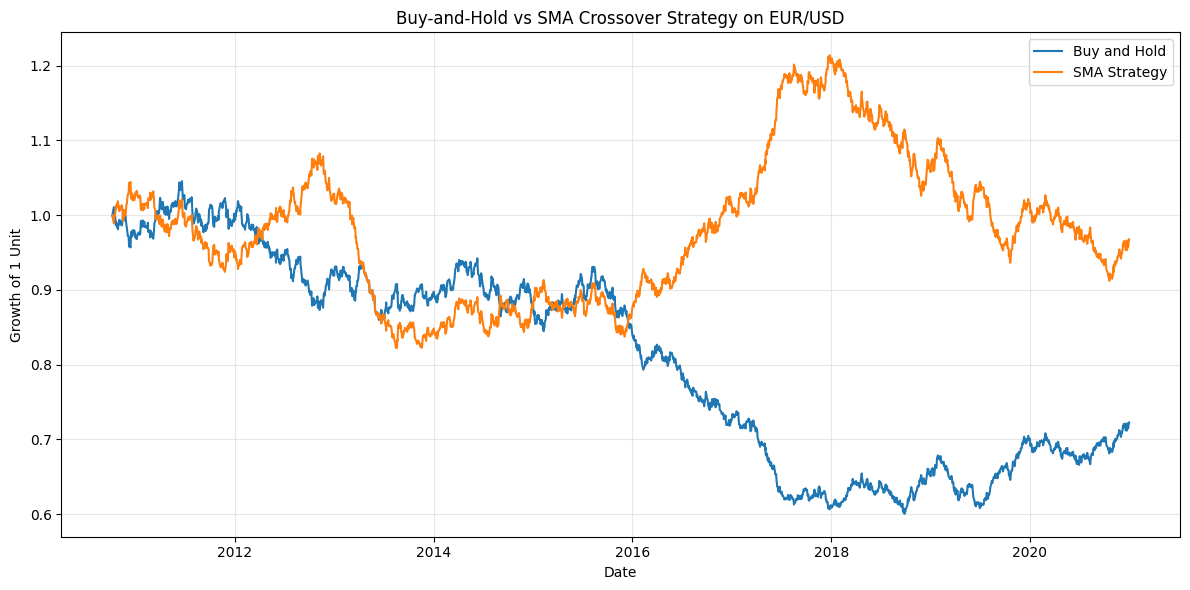

In [7]:
# Growth of 1 unit invested for the benchmark and the strategy.
df["creturns"] = np.exp(df["returns"].cumsum())
df["cstrategy"] = np.exp(df["strategy"].cumsum())

plt.figure(figsize=(12, 6))
plt.plot(df.index, df["creturns"], label="Buy and Hold")
plt.plot(df.index, df["cstrategy"], label="SMA Strategy")
plt.title("Buy-and-Hold vs SMA Crossover Strategy on EUR/USD")
plt.xlabel("Date")
plt.ylabel("Growth of 1 Unit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Outperformance Relative to the Benchmark

A strategy should beat its benchmark **before costs**. If it does not clearly outperform before transaction costs, slippage, and spreads, it is unlikely to remain attractive after those frictions are included.


In [8]:
outperformance = strategy_terminal_value - buy_hold_terminal_value

print(f"Buy-and-hold terminal value: {buy_hold_terminal_value:.6f}")
print(f"Strategy terminal value:     {strategy_terminal_value:.6f}")
print(f"Strategy outperformance:     {outperformance:.6f}")


Buy-and-hold terminal value: 0.722559
Strategy terminal value:     0.967619
Strategy outperformance:     0.245060


## 9. Interpretation

Vectorized backtesting means we use whole `pandas` Series and DataFrames to calculate signals and returns across the entire sample at once, instead of stepping through rows in a loop.

This approach is efficient, concise, and easy to inspect. It is especially useful when we want to prototype ideas quickly. However, apparent outperformance can be unstable across time periods, and this notebook does **not** include trading costs, spreads, or slippage.

So while the results are useful for learning and first-pass research, they should be treated as a simple educational illustration rather than a production-ready trading system.


## Key Takeaways

- Vectorized backtesting lets us evaluate a trading rule quickly with clean `pandas` code.
- The SMA crossover strategy compares a short trend with a long trend to switch between long and short positions.
- Strategy returns must use a **shifted** position to avoid look-ahead bias.
- Cumulative performance makes it easy to compare a strategy with buy-and-hold.
- Outperformance should be convincing before costs, otherwise the strategy is unlikely to survive realistic frictions.
- A simple backtest is useful for learning, but it is only the beginning of proper strategy evaluation.
